# LaTeX Preparation

## Main Results

In [1]:
import numpy as np
import os

from constants import (
    OBJECTIVE_FUNCTIONS_NAMES,
    ACQ_TYPE_MAPPING,
    ALGO_FILE_COUNT,
    LLMGP_NUMERICAL_RESULTS_DIR,
    NUMERICAL_RESULTS_DIR,
    EXP_RUNS,
)

def read_raw_result(problem, acq_type, result_type):
    raw_result = []
    for exp_idx in range(EXP_RUNS):
        try:
            if acq_type == "llmgp":
                file_name = f"{LLMGP_NUMERICAL_RESULTS_DIR}/{problem}/llmgp/{exp_idx}_{result_type}.npy"
            else:
                file_name = f"{NUMERICAL_RESULTS_DIR}/{problem}/{acq_type}/{exp_idx}_{result_type}.npy"
            result_sequence = np.load(file_name)
            if np.isnan(result_sequence).any():
                print(f"Found nan value in {file_name}")
                os.remove(file_name)  # Remove the file if it contains NaN values
                continue
            # if result_type is "simple_regret", check if any number is negative and print file name:
            if result_type == "simple_regret" and any(result < 0 for result in result_sequence):
                print(f"Found negative value in {file_name}")
                return []
            raw_result.append(result_sequence)
        except FileNotFoundError:
            continue 
    return raw_result

def get_agg_result(raw_result, agg):
    if agg == "auc":
        agg_result = [np.trapezoid(result.squeeze(), dx=1.0).item() for result in raw_result]
    elif agg == "mean":
        agg_result = [np.mean(result) for result in raw_result]
    elif agg == "last":
        agg_result = [result[-1] for result in raw_result]
    return agg_result

def get_all_problem_raw_result(problem_list, method_list, result_type):
    problem_result = {}
    for problem in problem_list:
        problem_result[problem] = {}
        for method in method_list:
            problem_result[problem][method] = read_raw_result(problem, method, result_type)
    return problem_result

def find_best_result_per_problem(result_by_all_methods):
    # set best to infty
    best_result = float("inf")
    for _, results in result_by_all_methods.items():
        for result in results:
            if result < best_result:
                best_result = result
    return best_result


In [ ]:
all_methods = list(ACQ_TYPE_MAPPING.keys())
all_methods.extend(list(ALGO_FILE_COUNT.keys()))
# Load all results
all_raw_results = get_all_problem_raw_result(OBJECTIVE_FUNCTIONS_NAMES, all_methods, "train_Y")
## Find the minimum value for each problem to use as the empirical optimum

# Aggregate
best_results_by_problem = {}
for problem in OBJECTIVE_FUNCTIONS_NAMES:
    best_results_by_problem[problem] = find_best_result_per_problem(all_results[problem])
    # Compute relative performance
    for method in all_methods:
        all_results[problem][method] = [
            result / best_results_by_problem[problem] for result in all_results[problem][method]
        ]
## Aggregate by method
all_results_by_method = {method: [] for method in all_methods}
for problem, results_by_method in all_results.items():
    for method, results_by_run in results_by_method.items():
        all_results_by_method[method].extend(results_by_run)
method_performance = {}
for method in all_methods:
    if len(all_results_by_method[method]) > 0:
        method_performance[method] = {
            "min": min(all_results_by_method[method]),
            "max": max(all_results_by_method[method]),
            "mean": sum(all_results_by_method[method]) / len(all_results_by_method[method]),
        }
# Rank
method_ranking = sorted(method_performance.items(), key=lambda x: x[1]["mean"])
## Print by rank with mean (min, max)


Found negative value in numerical_results/Cosine8/llambo/0_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/1_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/2_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/3_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/4_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/5_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/6_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/7_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/8_simple_regret.npy
Found negative value in numerical_results/Cosine8/llambo/9_simple_regret.npy
Found negative value in numerical_results/SixHumpCamel/PI/4_simple_regret.npy
Found negative value in numerical_results/SixHumpCamel/lmabo-ab3/7_simple_regret.npy
Found negative value in numerical_results/SixHumpCamel/bo_alternati

In [28]:
result = np.load("numerical_results/Sphere/PI/2_simple_regret.npy")
result

array([ 2.01177512e+01,  1.26144857e+01,  1.26144857e+01,  5.18458777e+00,
        5.18458777e+00,  5.18458777e+00,  3.43772319e+00,  3.42120031e+00,
        3.42120031e+00,  3.42120031e+00,  3.42120031e+00,  3.36663550e+00,
        2.86436678e+00,  1.52658109e+00,  6.54163342e-01,  3.31646548e-01,
        1.77275266e-01,  1.34945145e-01,  1.25002181e-01,  1.20049882e-01,
        1.20049882e-01,  1.14588864e-01,  1.14588864e-01,  1.14588864e-01,
        1.14200922e-01,  1.14200922e-01,  9.45728551e-02,  7.65615745e-02,
        7.60146195e-02,  7.60146195e-02,  7.41576427e-02,  7.41576427e-02,
        7.41576427e-02,  6.56797283e-02,  6.56797283e-02,  5.88317766e-02,
        5.88317766e-02,  5.34050446e-02,  5.34050446e-02,  3.88380150e-02,
        3.88380150e-02,  3.14041270e-02,  3.14041270e-02, -3.53595111e-03,
       -2.45096540e-02, -3.00041470e-02, -3.00041470e-02, -3.15271146e-02,
       -3.15271146e-02, -3.15271146e-02, -3.15271146e-02])

In [29]:
result = np.load("numerical_results/Sphere/PI/2_train_Y.npy")
result

array([190.00497231, 121.20962684,  99.63655118, 128.4777114 ,
       143.47235298, 103.5763485 , 141.41594986, 143.08737774,
       137.78956197, 179.34838011, 123.2674263 ,  92.13328575,
       129.70863884,  84.70338777,  85.16244412, 112.31034849,
        82.95652319,  82.94000031,  83.02254732,  82.99767328,
        82.95832426,  82.8854355 ,  82.38316678,  81.04538109,
        80.17296334,  79.85044655,  79.69607527,  79.65374514,
        79.64380218,  79.63884988,  79.63955835,  79.63338886,
        79.63401735,  79.63527926,  79.63300092,  79.67190928,
        79.61337286,  79.59536157,  79.59481462,  79.61229665,
        79.59295764,  79.59855106,  79.60083156,  79.58447973,
        79.62266149,  79.57763178,  79.5845066 ,  79.57220504,
        79.57491977,  79.55763802,  79.57045599,  79.55020413,
        79.62184258,  79.51526405,  79.49429035,  79.48879585,
        79.49504108,  79.48727289,  79.48780275,  79.49319647,
        79.48773102])

In [24]:
result = np.load("numerical_results/SharpRidge/LogEI/0_train_Y.npy")
result

array([ 885.34062788, 2623.26691928, 1294.24111689, 2327.41004288,
       1667.9749862 ,  694.05440586, 1977.36063562,  618.3441703 ,
       1104.63819588,  678.41545965, 1874.94466785,  580.02265877,
        532.99091093, 1030.13941758,  276.22141417,  653.66362119,
        597.57210678,  496.58682853,  849.84100774,  960.19707027,
        279.66422018,  868.03923569,  151.01785708,  326.54859686,
       1295.60981832,  252.81679128,  130.85140713,  167.25488309,
        160.29101518,  168.78101989,  189.95839325,  164.01465051,
        139.88724859,  220.27880854,  686.8211007 ,  164.08041708,
        130.86055061,  102.07101442,  520.9293761 , 1139.15833661,
        486.43043777, 1681.44468606,  167.27721534,  278.87459962,
        279.16864088,  354.25937421, 1017.50160019,  166.36533437,
       1581.12698622, 1574.81231361, 1333.06997048,  399.25914066,
        775.28574389,   99.34894062,  143.68572485,  116.9123715 ,
        208.40551302,  400.63901261,   60.43327475, 1853.67349

# AF Frequency

Show the overall selection of AFs by LMABO.

## Overall frequency

In [ ]:
from constants import OBJECTIVE_FUNCTIONS_NAMES

def load_af_choices(problem):
    folder_path = f"numerical_results/{problem}/lmabo"
    af_choices = {}
    for i in range(10):
        file_path = f"{folder_path}/{i}_acq_types.txt"
        with open(file_path, 'r') as file:
            # each AF sits in a line
            af_choices[i] = [af for af in file.read().splitlines() if af]
    return af_choices

def load_all_af_choices():
    all_af_choices = {}
    for problem in OBJECTIVE_FUNCTIONS_NAMES:
        all_af_choices[problem] = load_af_choices(problem)
    return all_af_choices

/home/s222509501/.conda/envs/lmabo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


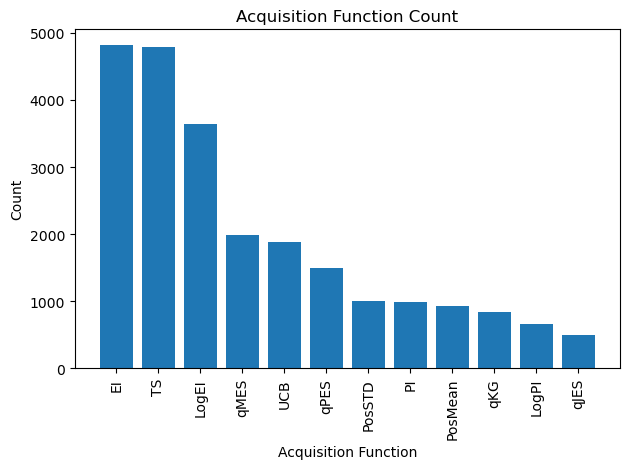

In [2]:
all_af_choices = load_all_af_choices()
# count all AFs
af_count = {}
for problem, problem_choices in all_af_choices.items():
    for i, afs in problem_choices.items():
        for af in afs:
            if af not in af_count:
                af_count[af] = 0
            af_count[af] += 1
# plot the sorted AF count by a bar chart
import matplotlib.pyplot as plt
af_count = dict(sorted(af_count.items(), key=lambda item: item[1], reverse=True))
plt.bar(af_count.keys(), af_count.values())
plt.xticks(rotation=90)
plt.xlabel('Acquisition Function')
plt.ylabel('Count')
plt.title('Acquisition Function Count')
plt.tight_layout()
plt.show()

## Dataset-specific frequency

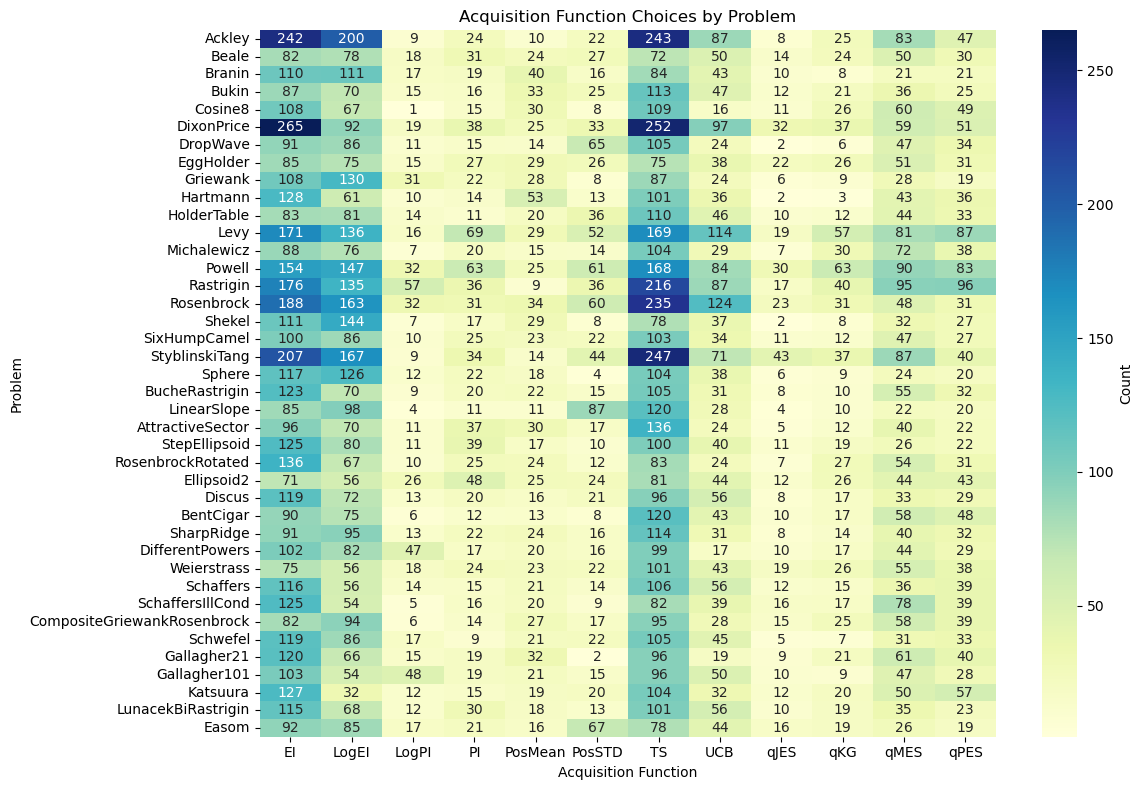

In [3]:
# Plot the AF choices for each problem by a heatmap
# For each problem, count the number of choices for each AF
# Create a dataframe where rows are problems and columns are AF choices
import seaborn as sns
import numpy as np
import pandas as pd
problems = list(all_af_choices.keys())
af_count_by_problem = {problem: {af: 0 for af in af_count.keys()} for problem in problems}
for problem, choices in all_af_choices.items():
    for i, afs in choices.items():
        for af in afs:
            af_count_by_problem[problem][af] += 1
af_df = pd.DataFrame(af_count_by_problem).T.fillna(0)
af_df = af_df[sorted(af_df.columns)]
plt.figure(figsize=(12, 8))
sns.heatmap(af_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count'})
plt.xlabel('Acquisition Function')
plt.ylabel('Problem')
plt.title('Acquisition Function Choices by Problem')
plt.tight_layout()
plt.show()

# Temporal Analysis

## AF choice by iteration

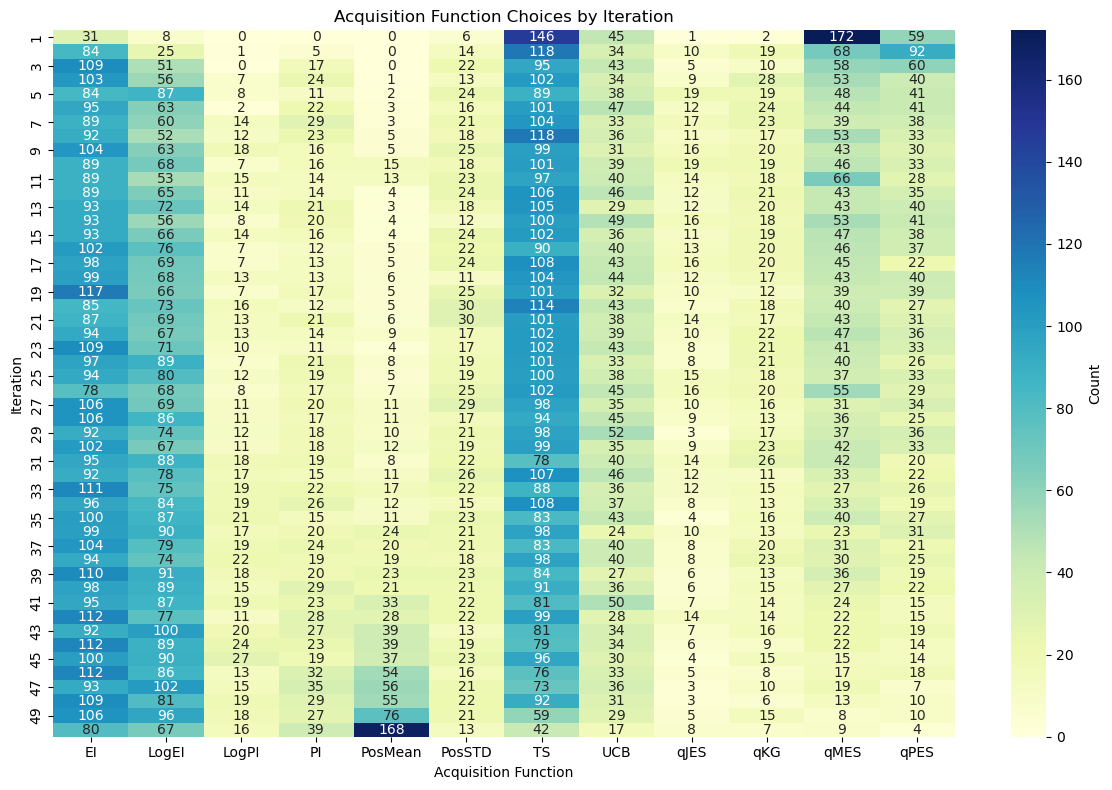

In [ ]:
# Count the frequency of each AF per iteration across all problems
# We either have 50 or 100 iterations, depending on the problem, so we will group by 50
# Create a dataframe where rows are iterations and columns are AF choices
# For problems with 100 iterations, we will group them by 50, which means iterations 1 and 2 will be grouped together, 3 and 4, etc.
af_count_by_iteration = {i: {af: 0 for af in af_count.keys()} for i in range(1, 51)}
for problem, choices in all_af_choices.items():
    for afs in choices.values():
        for j, af in enumerate(afs):
            # Group by 50 iterations
            if len(afs) == 50:
                iteration = j + 1
            else:
                # For 100 iterations, we group them by 50
                if j % 2 == 0:  # even index means first of the pair
                    iteration = (j // 2) + 1
            af_count_by_iteration[iteration][af] += 1
af_iter_df = pd.DataFrame(af_count_by_iteration).T.fillna(0)
af_iter_df = af_iter_df[sorted(af_iter_df.columns)]
plt.figure(figsize=(12, 8))
sns.heatmap(af_iter_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count'})
plt.xlabel('Acquisition Function')
plt.ylabel('Iteration')
plt.title('Acquisition Function Choices by Iteration')
plt.tight_layout()
plt.show()

## AF choice with switches

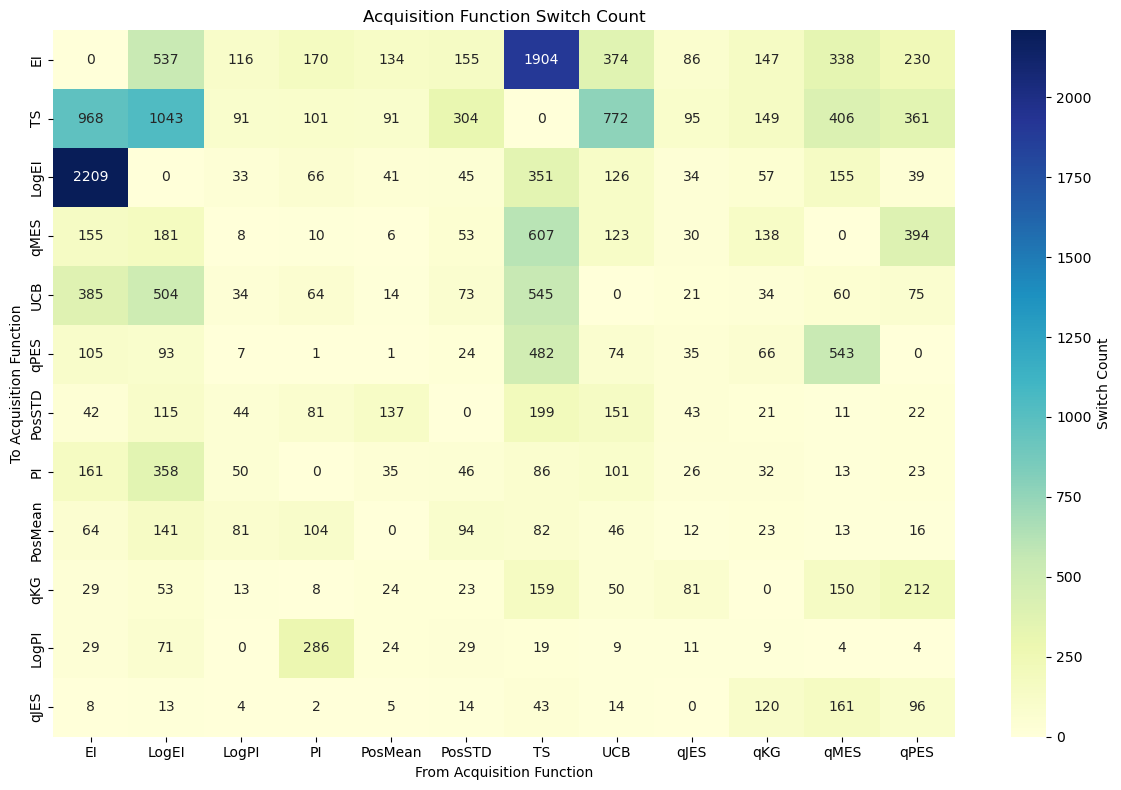

In [ ]:
# a heatmap of the number of times the algorithm switched from one AF to another
# For each problem, count the number of switches from one AF to another across all 10 runs
af_switch_count = {af: {af2: 0 for af2 in af_count.keys()} for af in af_count.keys()}
for problem, choices in all_af_choices.items():
    for afs in choices.values():
        for j in range(len(afs) - 1):
            af1 = afs[j]
            af2 = afs[j + 1]
            if af1 != af2:
                af_switch_count[af1][af2] += 1
af_switch_df = pd.DataFrame(af_switch_count).fillna(0)
af_switch_df = af_switch_df[sorted(af_switch_df.columns)]
plt.figure(figsize=(12, 8))
sns.heatmap(af_switch_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Switch Count'})
plt.xlabel('From Acquisition Function')
plt.ylabel('To Acquisition Function')
plt.title('Acquisition Function Switch Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4107518/235898415.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([switch_counts["50"], switch_counts["100"]], labels=["50 Iterations", "100 Iterations"])


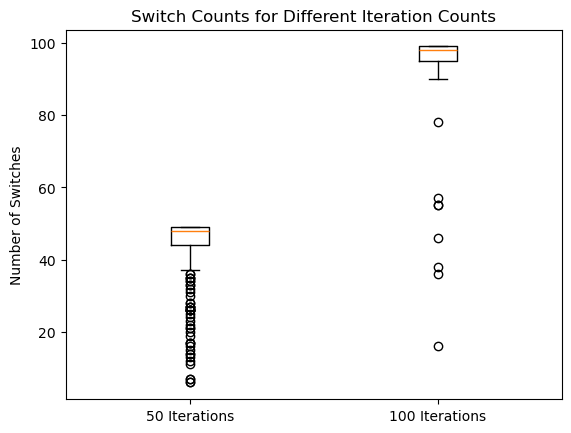

In [6]:
# I want to check how often does the algorithm switch from one AF to another in all_af_choices.
# Make separate counts for runs with 50 iterations and 100 iterations.

switch_counts = {
    "50": [],
    "100": []
}

for all_choices_by_problem in all_af_choices.values():
    for choices in all_choices_by_problem.values():
        switch_count = 0
        for i in range(len(choices) - 1):
            if choices[i] != choices[i + 1]:
                switch_count += 1
        if len(choices) == 50:
            switch_counts["50"].append(switch_count)
        else:
            switch_counts["100"].append(switch_count)
# Now present the two as boxplots
import matplotlib.pyplot as plt

plt.boxplot([switch_counts["50"], switch_counts["100"]], labels=["50 Iterations", "100 Iterations"])
plt.ylabel("Number of Switches")
plt.title("Switch Counts for Different Iteration Counts")
plt.show()

In [7]:
avg_50 = sum(switch_counts["50"]) / len(switch_counts["50"])
avg_100 = sum(switch_counts["100"]) / len(switch_counts["100"])
print(f"Average switch count for 50 iterations: {avg_50:.2f}")
print(f"Average switch count for 100 iterations: {avg_100:.2f}")

Average switch count for 50 iterations: 43.97
Average switch count for 100 iterations: 91.60


# State-conditioned Analysis

## Stagnation vs Improvement

In [ ]:
# first define functions to load the simple regret of LMABO, modified from load_af_choices and load_all_af_choices

from constants import OBJECTIVE_FUNCTIONS_NAMES

def load_simple_regret(problem):
    folder_path = f"numerical_results/{problem}/lmabo"
    simple_regret = {}
    for i in range(10):
        file_path = f"{folder_path}/{i}_simple_regret.npy"
        simple_regret[i] = np.load(file_path)
    return simple_regret

def load_all_simple_regret():
    all_simple_regret = {}
    for problem in OBJECTIVE_FUNCTIONS_NAMES:
        all_simple_regret[problem] = load_simple_regret(problem)
    return all_simple_regret


In [9]:
# Load all simple regret data
all_simple_regret = load_all_simple_regret()
# Define stagnation and improvement criteria
threshold = 1e-5
# Convert simple regret to stagnation or improvement
# True (improvement) if the simple regret reduces more than the threshold
# False (stagnation) if the simple regret does not reduce more than the threshold
# Do this for each array where an array of N iterations is converted to a list of N binary labels
all_simple_regret_status = {}
for problem in all_simple_regret.keys():
    all_simple_regret_status[problem] = {}
    for i, simple_regret in all_simple_regret[problem].items():
        # Convert to stagnation or improvement
        status = [(simple_regret[j] - simple_regret[j + 1]).item() > threshold for j in range(len(simple_regret) - 1)]
        all_simple_regret_status[problem][i] = status

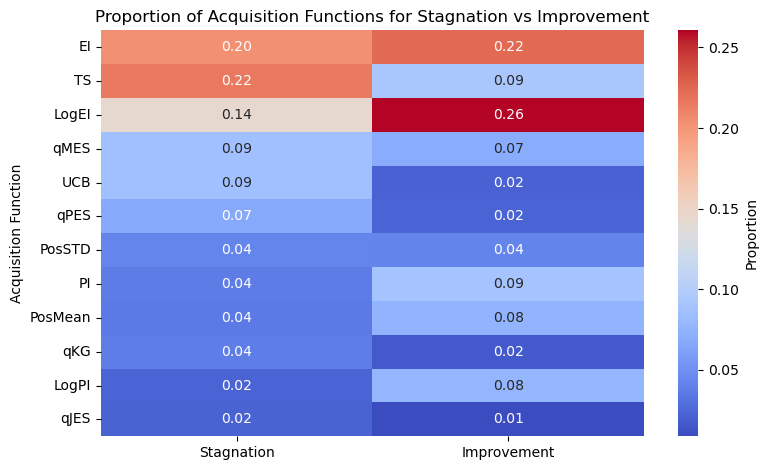

In [10]:
# Now we combine all_simple_regret_status and all_af_choices to count the number of stagnations and improvements for each AF type.
af_combined_status = {af: {"Stagnation": 0, "Improvement": 0} for af in af_count.keys()}
for problem, simple_regret_status_by_problem in all_simple_regret_status.items():
    af_choices_by_problem = all_af_choices[problem]
    for i, status_series in simple_regret_status_by_problem.items():
        af_series = af_choices_by_problem[i]
        for j, status in enumerate(status_series):
                af = af_series[j]
                # Count stagnation and improvement
                if status:
                    af_combined_status[af]["Improvement"] = af_combined_status[af].get("Improvement", 0) + 1
                else:
                    af_combined_status[af]["Stagnation"] = af_combined_status[af].get("Stagnation", 0) + 1

# Create a dataframe for heatmap: rows are AFs, columns are ["Stagnation", "Improvement"], values are proportions across the columns
af_status_df = pd.DataFrame(af_combined_status).T
improvement_total = af_status_df["Improvement"].sum()
stagnation_total = af_status_df["Stagnation"].sum()
af_status_df["Stagnation_prop"] = af_status_df["Stagnation"] / stagnation_total
af_status_df["Improvement_prop"] = af_status_df["Improvement"] / improvement_total
heatmap_df = af_status_df[["Stagnation_prop", "Improvement_prop"]]
heatmap_df = heatmap_df.rename(columns={"Stagnation_prop": "Stagnation", "Improvement_prop": "Improvement"})

plt.figure(figsize=(8, len(heatmap_df) * 0.4))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Proportion'})
plt.ylabel("Acquisition Function")
plt.title("Proportion of Acquisition Functions for Stagnation vs Improvement")
plt.tight_layout()
plt.show()

## Correlation with GP model parameters

In [11]:
import re
import pandas as pd

log_path = "log/Rosenbrock_lmabo.out"

def read_params_af_log(log_path):
    # Patterns for extraction
    run_pattern = re.compile(r"RUN (\d+)")
    iter_pattern = re.compile(r"Iter (\d+)")
    lengthscale_pattern = re.compile(
        r"Lengthscales: Range \[([0-9.eE+-]+), ([0-9.eE+-]+)\], Mean ([0-9.eE+-]+) \(Std Dev ([0-9.eE+-]+)\)"
    )
    outputscale_pattern = re.compile(r"Outputscale: ([0-9.eE+-]+)")
    shortest_dist_pattern = re.compile(r"Shortest distance: ([0-9.eE+-]+)")
    llm_af_pattern = re.compile(r"^(EI|TS|UCB|LogEI|qPES|qMES|qJES|qKG|PI|LogPI|PosSTD|PosMean):|LLM suggested AF: ([A-Za-z0-9]+)")

    results = []
    current_run = None
    current_iter = None

    with open(log_path, "r") as f:
        for line in f:
            # Detect run
            run_match = run_pattern.match(line)
            if run_match:
                current_run = int(run_match.group(1))
                continue

            # Detect iteration
            iter_match = iter_pattern.match(line)
            if iter_match:
                current_iter = int(iter_match.group(1))
                continue

            # Extract lengthscale
            lengthscale_match = lengthscale_pattern.search(line)
            if lengthscale_match:
                ls_min = float(lengthscale_match.group(1))
                ls_max = float(lengthscale_match.group(2))
                ls_mean = float(lengthscale_match.group(3))
                ls_std = float(lengthscale_match.group(4))
                continue

            # Extract outputscale
            outputscale_match = outputscale_pattern.search(line)
            if outputscale_match:
                outputscale = float(outputscale_match.group(1))
                continue

            # Extract shortest distance
            shortest_dist_match = shortest_dist_pattern.search(line)
            if shortest_dist_match:
                shortest_dist = float(shortest_dist_match.group(1))
                continue

            # Extract AF
            af_match = llm_af_pattern.search(line)
            if af_match:
                af = af_match.group(1) if af_match.group(1) else af_match.group(2)
                # Save only if all fields are present
                if current_run is not None and current_iter is not None:
                    results.append({
                        "run": current_run,
                        "iteration": current_iter,
                        "lengthscale_min": ls_min,
                        "lengthscale_max": ls_max,
                        "lengthscale_mean": ls_mean,
                        "lengthscale_std": ls_std,
                        "outputscale": outputscale,
                        "shortest_distance": shortest_dist,
                        "af": af
                    })
    return pd.DataFrame(results)

# Example: print first 5 entries
params_af_df = read_params_af_log(log_path)
print(params_af_df.shape)
params_af_df.head()

(1012, 9)


,run,iteration,lengthscale_min,lengthscale_max,lengthscale_mean,lengthscale_std,outputscale,shortest_distance,af
0,0,0,0.803,97.820,46.310,37.493,2.345512,1.747947,qPES
1,0,1,0.803,97.820,46.310,37.493,2.345512,1.717258,qKG
2,0,2,0.931,128.926,55.030,44.857,2.759542,1.636202,UCB
3,0,3,0.846,815.284,315.783,267.722,2.652855,2.083167,EI
4,0,4,0.696,220.689,90.172,68.322,2.462569,1.470775,LogEI


In [12]:
# Summarize the frequence of af
af_frequency = params_af_df['af'].value_counts()
print("Frequency of Acquisition Functions:")
print(af_frequency)

Frequency of Acquisition Functions:
af
TS         240
EI         194
LogEI      163
UCB        125
PosSTD      60
qMES        48
PosMean     34
LogPI       32
qPES        31
qKG         31
PI          31
qJES        23
Name: count, dtype: int64


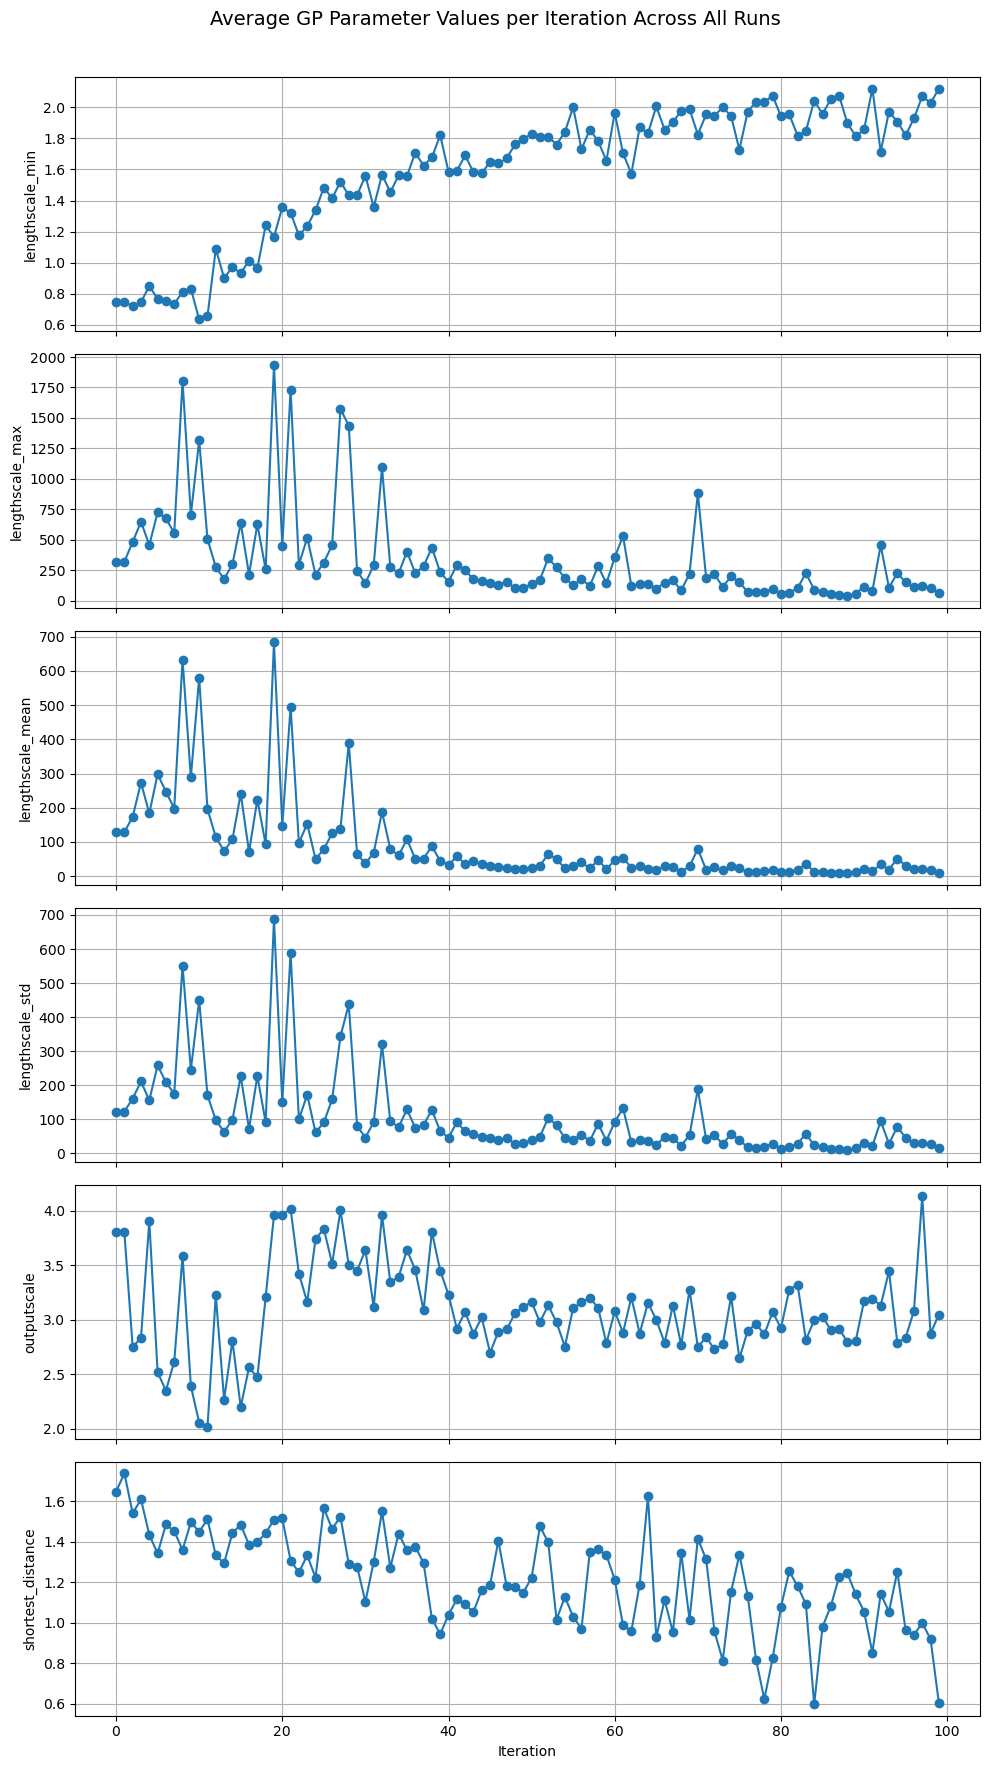

In [13]:
import matplotlib.pyplot as plt

numerical_cols = ['lengthscale_min', 'lengthscale_max', 'lengthscale_mean', 'lengthscale_std', 'outputscale', 'shortest_distance']

avg_by_iter = params_af_df.groupby('iteration')[numerical_cols].mean()

fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 3 * len(numerical_cols)), sharex=True)
for idx, col in enumerate(numerical_cols):
    axes[idx].plot(avg_by_iter.index, avg_by_iter[col], marker='o')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True)
axes[-1].set_xlabel('Iteration')
fig.suptitle('Average GP Parameter Values per Iteration Across All Runs', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

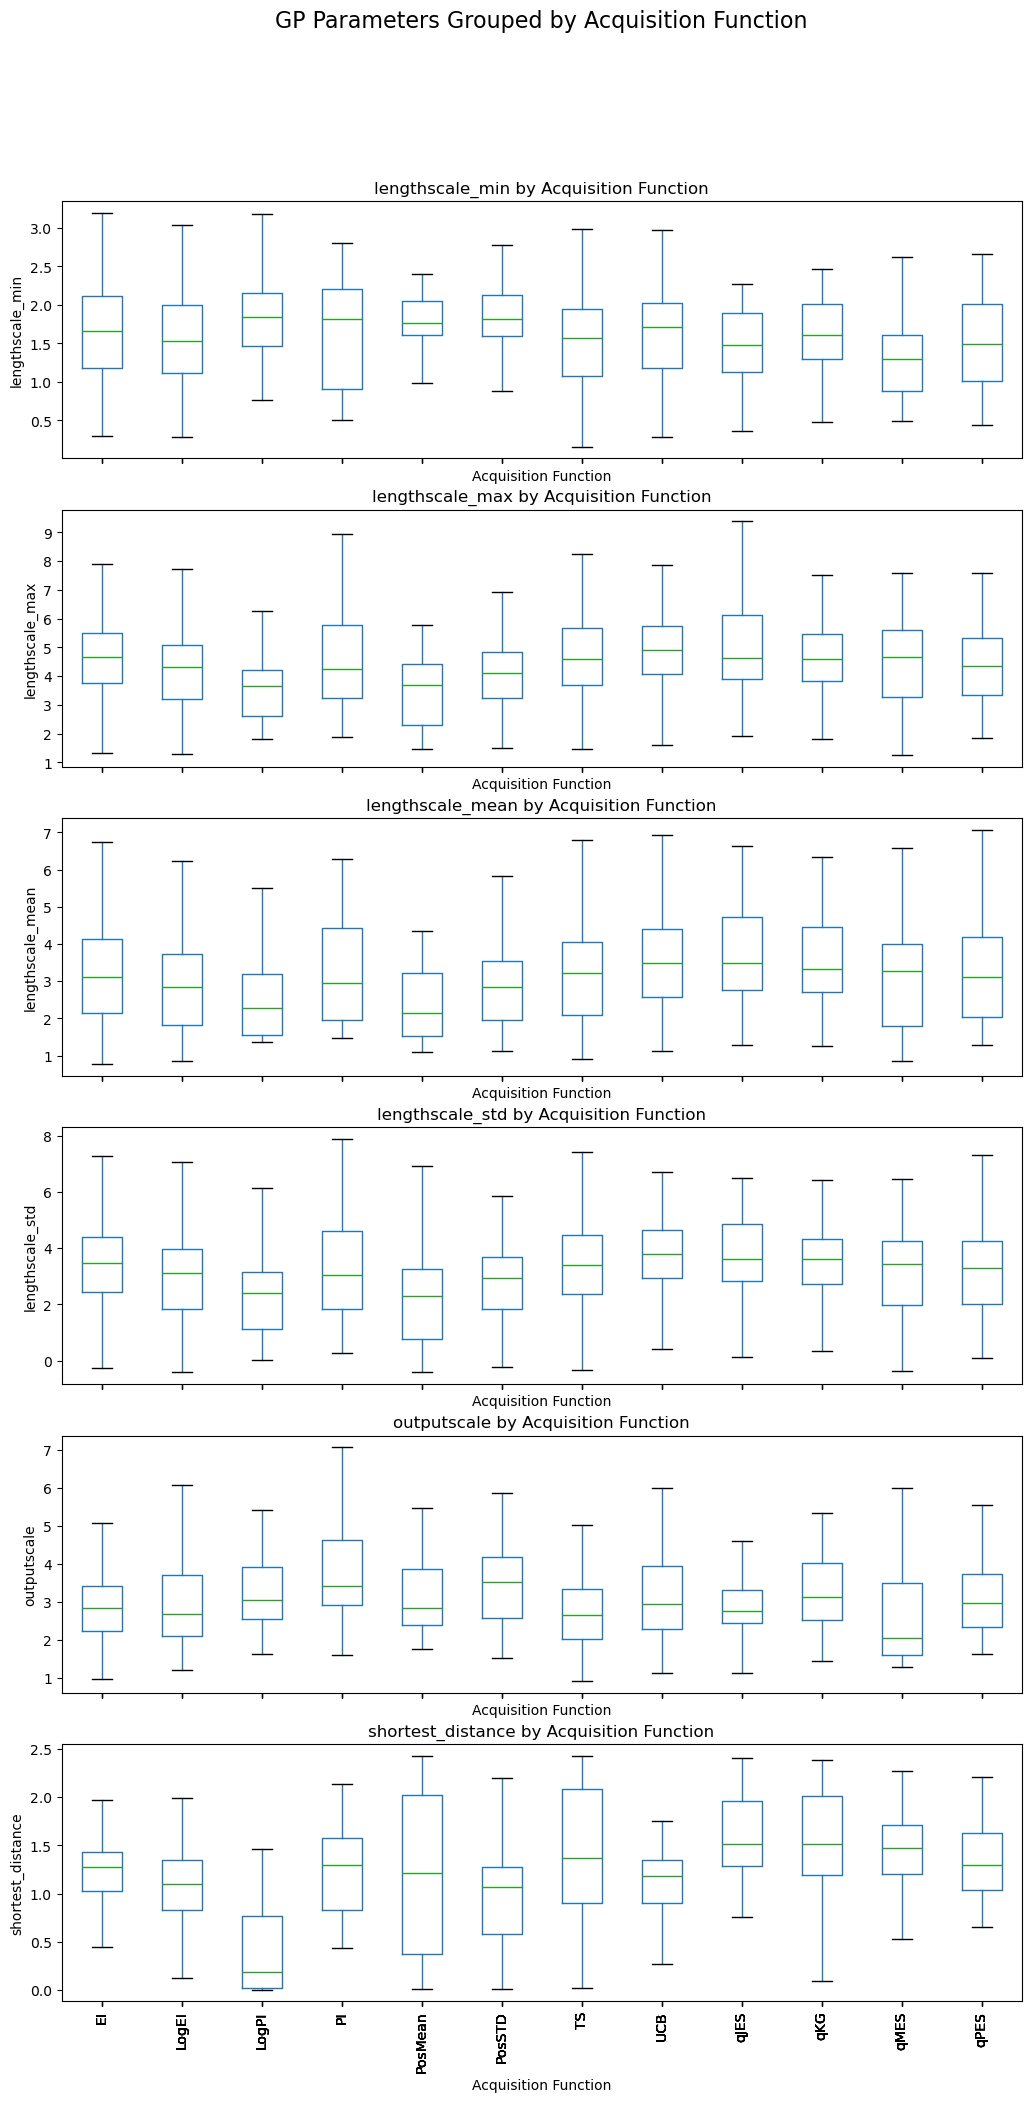

In [14]:
import matplotlib.pyplot as plt

# List of numerical columns to plot
numerical_cols = ['lengthscale_min', 'lengthscale_max', 'lengthscale_mean', 'lengthscale_std', 'outputscale', 'shortest_distance']

# Create a boxplot for each parameter grouped by acquisition function
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 4 * len(numerical_cols)), sharex=True)
for idx, col in enumerate(numerical_cols):
    # convert lengthscale_max, lengthscale_mean, lengthscale_std to log scale
    if col in ['lengthscale_max', 'lengthscale_mean', 'lengthscale_std']:
        params_af_df[col] = params_af_df[col].apply(lambda x: np.log(x) if x > 0 else 0)
    params_af_df.boxplot(column=col, by='af', ax=axes[idx], grid=False, showfliers=False)
    axes[idx].set_title(f'{col} by Acquisition Function')
    # we need to show the acquisition function names for xticks for all boxplots
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=90)
    axes[idx].set_xlabel('Acquisition Function')
    axes[idx].set_ylabel(col)
    # axes[idx].tick_params(axis='x', rotation=90)
plt.suptitle('GP Parameters Grouped by Acquisition Function', fontsize=16)
plt.show()

In [15]:
# aggregate the numerical columns by af
agg_params_af_df = params_af_df.groupby('af')[numerical_cols].agg(['mean']).reset_index()
agg_params_af_df.columns = ['af'] + [f"{col}_{stat}" for col, stat in agg_params_af_df.columns[1:]]
agg_params_af_df

,af,lengthscale_min_mean,lengthscale_max_mean,lengthscale_mean_mean,lengthscale_std_mean,outputscale_mean,shortest_distance_mean
0,EI,1.619160,4.572873,3.245282,3.277238,3.028389,1.204423
1,LogEI,1.556104,4.193526,2.962733,2.892134,2.975174,1.069281
2,LogPI,1.761500,3.684661,2.605846,2.363688,3.294331,0.476889
3,PI,1.652903,4.468750,3.416315,3.221867,3.788019,1.215337
4,PosMean,1.807441,3.597637,2.455618,2.215376,3.156552,1.174797
5,PosSTD,1.781417,4.149840,2.960002,2.862324,3.403858,0.943274
6,TS,1.531642,4.599824,3.265525,3.309305,2.887358,1.414781
7,UCB,1.642944,4.823361,3.479456,3.567553,3.243222,1.074618
8,qJES,1.466957,4.910106,3.777197,3.708031,3.214642,1.582823
9,qKG,1.605871,4.595469,3.452242,3.380296,3.754178,1.543470


In [16]:
explorative_group = ['UCB', 'TS', 'qKG', 'qMES', 'qPES', 'qJES', 'PosSTD']
exploitative_group = ['EI', 'LogEI', 'PI', 'LogPI', 'PosMean']
# get the summary statistics for each group by taking the mean of the columns
explorative_df = agg_params_af_df[agg_params_af_df['af'].isin(explorative_group)]
print("Explorative")
print(explorative_df.mean(axis=0, numeric_only=True))
exploitative_df = agg_params_af_df[agg_params_af_df['af'].isin(exploitative_group)]
print("Exploitative")
print(exploitative_df.mean(axis=0, numeric_only=True))


Explorative
lengthscale_min_mean      1.553837
lengthscale_max_mean      4.576830
lengthscale_mean_mean     3.360934
lengthscale_std_mean      3.327555
outputscale_mean          3.220792
shortest_distance_mean    1.337995
dtype: float64
Exploitative
lengthscale_min_mean      1.679422
lengthscale_max_mean      4.103489
lengthscale_mean_mean     2.937159
lengthscale_std_mean      2.794061
outputscale_mean          3.248493
shortest_distance_mean    1.028146
dtype: float64


In [17]:
from scipy import stats

explorative_group = ['UCB', 'TS', 'qKG', 'qMES', 'qPES', 'qJES', 'PosSTD']
exploitative_group = ['EI', 'LogEI', 'PI', 'LogPI', 'PosMean']

def stat_test(group1, group2):
    # perform Mann-Whitney U test
    _, p = stats.mannwhitneyu(group1, group2)
    return p < 0.05

def stat_test_by_problem(problem):
    # for each column we want different things
    # lengthscale_min: test if explorative is smaller
    # lengthscale_max: test if explorative is bigger
    # lengthscale_mean: test if explorative is bigger
    # lengthscale_std: test if explorative is bigger
    # outputscale: test if explorative is bigger
    # shortest_distance: test if explorative is bigger

    col_names = ['lengthscale_min', 'lengthscale_max', 'lengthscale_mean', 'lengthscale_std', 'outputscale', 'shortest_distance']
    tests = ['less', 'greater', 'greater', 'greater', 'greater', 'greater']

    log_path = f"log/{problem}_lmabo.out"
    params_af_df = read_params_af_log(log_path)
    # do not run if empty
    if params_af_df.empty:
        print(f"No data found for {problem}. Skipping...")
        return None
    params_af_df['group'] = params_af_df['af'].apply(lambda x: 'Explorative' if x in explorative_group else 'Exploitative')
    result = {'problem': problem, 'nrows': params_af_df.shape[0], 'lengthscale_max_mean': params_af_df['lengthscale_max'].mean()}

    for col, test in zip(col_names, tests): 
        group1 = params_af_df[params_af_df['group'] == 'Explorative'][col]
        group2 = params_af_df[params_af_df['group'] == 'Exploitative'][col]
        _, p_value = stats.mannwhitneyu(group1, group2, alternative=test)
        result[col] = p_value.item()
    return result

In [ ]:
from constants import OBJECTIVE_FUNCTIONS_NAMES
# loop over all problems
all_results = []
for problem in OBJECTIVE_FUNCTIONS_NAMES:
    print(f"Processing {problem}...")
    result = stat_test_by_problem(problem)
    if result is not None:
        all_results.append(result)
# convert results to DataFrame
all_results_df = pd.DataFrame(all_results)
all_results_df.set_index('problem', inplace=True)

Processing Ackley...
Processing Beale...
No data found for Beale. Skipping...
Processing Branin...
Processing Bukin...
Processing Cosine8...
Processing DixonPrice...
Processing DropWave...
Processing EggHolder...
Processing Griewank...
Processing Hartmann...
Processing HolderTable...
Processing Levy...
Processing Michalewicz...
Processing Powell...
Processing Rastrigin...
Processing Rosenbrock...
Processing Shekel...
Processing SixHumpCamel...
Processing StyblinskiTang...
Processing Sphere...
Processing BucheRastrigin...
Processing LinearSlope...
Processing AttractiveSector...
Processing StepEllipsoid...
Processing RosenbrockRotated...
Processing Ellipsoid2...
Processing Discus...
Processing BentCigar...
Processing SharpRidge...
Processing DifferentPowers...
Processing Weierstrass...
Processing Schaffers...
Processing SchaffersIllCond...
Processing CompositeGriewankRosenbrock...
Processing Schwefel...
Processing Gallagher21...
Processing Gallagher101...
Processing Katsuura...
Processin

In [19]:
# sort dataframe by lengthscale_max_mean
all_results_df.sort_values(by='lengthscale_max_mean', inplace=True)
all_results_df

,nrows,lengthscale_max_mean,lengthscale_min,lengthscale_max,lengthscale_mean,lengthscale_std,outputscale,shortest_distance
problem,,,,,,,,
Branin,200,4.598965,7.624932e-03,9.914836e-01,9.882396e-01,9.958348e-01,9.999809e-01,4.869761e-14
SixHumpCamel,150,19.031407,6.253193e-07,9.809596e-01,9.964729e-01,6.448446e-01,9.999950e-01,3.847122e-04
Bukin,506,19.863953,7.957479e-01,4.016442e-01,2.414992e-01,5.506009e-01,1.820394e-03,9.489837e-04
HolderTable,150,49.236720,3.970627e-01,4.863237e-01,7.859192e-01,2.938865e-02,4.643490e-01,5.799684e-01
EggHolder,463,68.743419,4.212283e-02,3.913320e-03,1.216266e-01,8.072299e-05,2.105399e-03,1.168544e-02
DropWave,502,87.242333,5.988699e-05,5.110934e-05,1.446340e-03,1.763381e-07,1.336245e-06,7.819649e-01
LinearSlope,150,95.093260,8.376607e-01,1.519426e-01,1.411162e-01,1.528690e-01,1.376266e-01,9.405029e-01
Easom,50,175.902180,9.849313e-01,1.877288e-02,1.070114e-02,3.835793e-02,9.872554e-01,4.830542e-03
Shekel,163,178.352988,9.780838e-01,7.791953e-02,4.419538e-02,1.237053e-01,3.711931e-02,8.478832e-01


In [20]:
# create a new dataframe to from all_results_df to check if each cell is less than 0.05 for the last 5 columns
p_value_df = all_results_df.iloc[:, -5:].applymap(lambda x: x < 0.05)
p_value_df["nrows"] = all_results_df["nrows"]
p_value_df["lengthscale_max_mean"] = all_results_df["lengthscale_max_mean"]
p_value_df

/tmp/ipykernel_4107518/985202688.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  p_value_df = all_results_df.iloc[:, -5:].applymap(lambda x: x < 0.05)


,lengthscale_max,lengthscale_mean,lengthscale_std,outputscale,shortest_distance,nrows,lengthscale_max_mean
problem,,,,,,,
Branin,False,False,False,False,True,200,4.598965
SixHumpCamel,False,False,False,False,True,150,19.031407
Bukin,False,False,False,True,True,506,19.863953
HolderTable,False,False,True,False,False,150,49.236720
EggHolder,True,False,True,True,True,463,68.743419
DropWave,True,True,True,True,False,502,87.242333
LinearSlope,False,False,False,False,False,150,95.093260
Easom,True,True,True,False,True,50,175.902180
Shekel,False,True,False,True,False,163,178.352988


In [21]:
# sum each column of p_value_df
p_value_sums = p_value_df.sum()
p_value_sums

lengthscale_max            21.000000
lengthscale_mean           20.000000
lengthscale_std            22.000000
outputscale                 9.000000
shortest_distance          23.000000
nrows                    9175.000000
lengthscale_max_mean    43210.775834
dtype: float64

# Qualitative and Comparative Analysis

## Meta Strategies